<a href="https://colab.research.google.com/github/abhi-2411/urban-heat-island-modelling/blob/main/refined_uhi_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1 — Install & Imports
# ============================================================
!pip install shap -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import wilcoxon
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

RANDOM_STATE   = 42
TEST_SIZE      = 0.2
BUILTUP_THR    = 4976
TARGET         = 'LST'
SEASON_COLORS  = {'Summer': '#E8593C', 'PostMonsoon': '#3B8BD4'}
REGIME_COLORS  = {'Urban': '#E8593C', 'Rural': '#3B8BD4', 'Global': '#6B59CC'}

print("Libraries loaded.")


Libraries loaded.


In [ ]:

summer      = pd.read_csv('UHI_Extended_Summer_2023.csv')
postmonsoon = pd.read_csv('UHI_Extended_PostMonsoon_2023.csv')

summer['SeasonLabel']      = 'Summer'
postmonsoon['SeasonLabel'] = 'PostMonsoon'

df_all = pd.concat([summer, postmonsoon], ignore_index=True)

# Keep only relevant columns
keep = ['BuiltUp', 'LST_C', 'NDVI', 'MNDWI', 'elevation', 'LULC_ESA', 'SeasonLabel']
df_all = df_all[keep].copy()
df_all.rename(columns={'LST_C': 'LST'}, inplace=True)

print(f"Combined shape: {df_all.shape}")
print(f"\nSeason counts:\n{df_all['SeasonLabel'].value_counts()}")
print(f"\nLST by season:")
print(df_all.groupby('SeasonLabel')['LST'].describe().round(2))



Combined shape: (10000, 7)

Season counts:
SeasonLabel
Summer         5000
PostMonsoon    5000
Name: count, dtype: int64

LST by season:
              count   mean  std    min    25%    50%    75%    max
SeasonLabel                                                       
PostMonsoon  5000.0  33.00  3.4  16.68  31.75  33.57  34.94  45.65
Summer       5000.0  41.45  2.4  31.00  40.31  41.71  42.93  53.23


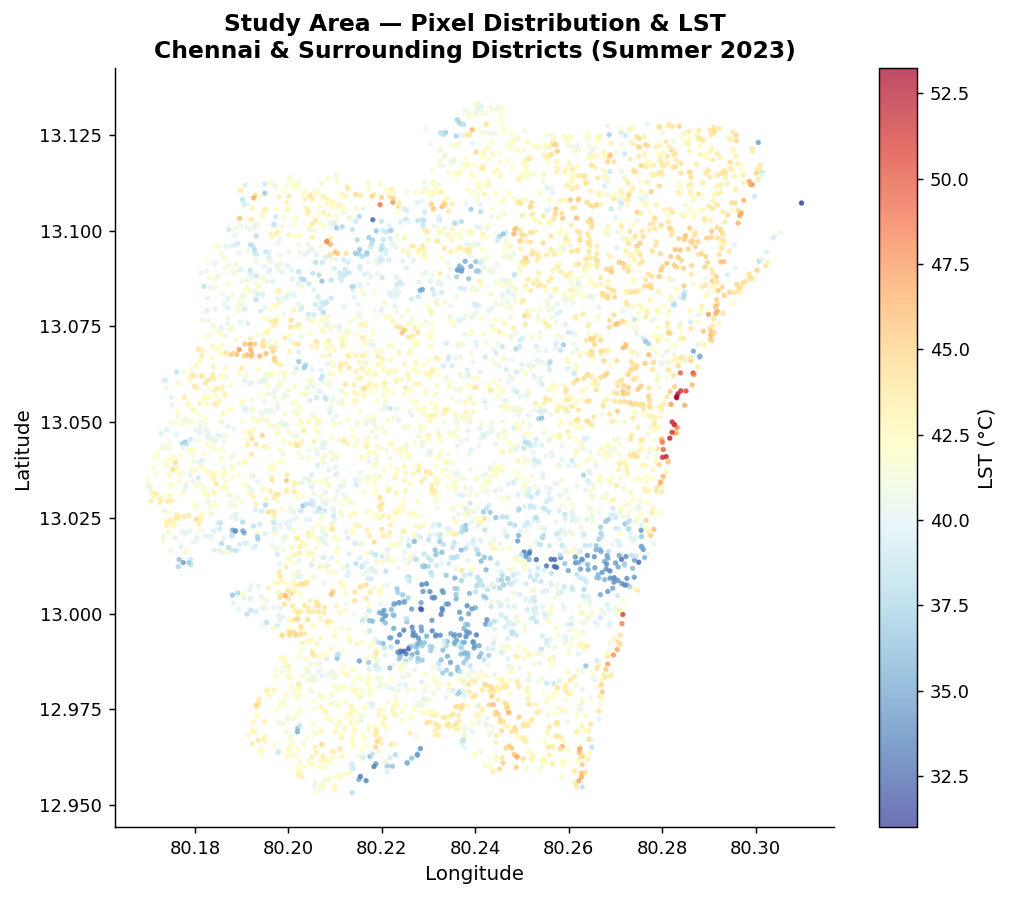

Coordinate range: Lon 80.170–80.310 | Lat 12.953–13.133


In [ ]:
# ============================================================
# CELL 2B — Study Area Map
# ============================================================
import ast

summer_raw = pd.read_csv('UHI_Extended_Summer_2023.csv')

# Parse coordinates from .geo column
def parse_coords(geo_str):
    try:
        geo = ast.literal_eval(geo_str)
        coords = geo['coordinates']
        if isinstance(coords[0], list):
            coords = coords[0]
        return coords[0], coords[1]
    except:
        return None, None

lons, lats = zip(*summer_raw['.geo'].apply(parse_coords))
lons = pd.Series(lons).astype(float)
lats = pd.Series(lats).astype(float)

fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(lons, lats,
                     c=summer_raw['LST_C'],
                     cmap='RdYlBu_r',
                     s=4, alpha=0.7,
                     rasterized=True)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('LST (°C)', fontsize=11)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Study Area — Pixel Distribution & LST\nChennai & Surrounding Districts (Summer 2023)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('00_StudyArea_Map.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Coordinate range: Lon {lons.min():.3f}–{lons.max():.3f} | Lat {lats.min():.3f}–{lats.max():.3f}")

In [ ]:
# CELL 3 — Clean + One-Hot Encode LULC + Drop Impervious
# ============================================================

# IQR outlier removal per season
def remove_outliers(df, col='LST'):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

n_before = len(df_all)
df_all = df_all.groupby('SeasonLabel', group_keys=False).apply(remove_outliers).reset_index(drop=True)

print(f"Pixels before cleaning : {n_before}")
print(f"Pixels after  cleaning : {len(df_all)}  ({n_before - len(df_all)} removed)")
print(f"\nLST range Summer      : {df_all[df_all.SeasonLabel=='Summer'].LST.min():.2f}°C  to  {df_all[df_all.SeasonLabel=='Summer'].LST.max():.2f}°C")
print(f"LST range PostMonsoon : {df_all[df_all.SeasonLabel=='PostMonsoon'].LST.min():.2f}°C  to  {df_all[df_all.SeasonLabel=='PostMonsoon'].LST.max():.2f}°C")

# FIX 1: One-hot encode LULC_ESA (it's categorical, not numeric)
lulc_dummies = pd.get_dummies(df_all['LULC_ESA'], prefix='LULC')
df_all = pd.concat([df_all.drop('LULC_ESA', axis=1), lulc_dummies], axis=1)

# FIX 2: Drop Impervious if present (95.7% constant = zero information)
if 'Impervious' in df_all.columns:
    df_all = df_all.drop('Impervious', axis=1)
    print("\nImpervious dropped (near-constant feature).")

# Define FEATURES after encoding
lulc_cols = sorted([c for c in df_all.columns if c.startswith('LULC_')])
FEATURES = ['BuiltUp', 'NDVI', 'MNDWI', 'elevation'] + lulc_cols

print(f"\nFinal features ({len(FEATURES)}): {FEATURES}")
print(f"\nDataset summary:")
df_all[FEATURES + ['LST']].describe().round(3)



Pixels before cleaning : 10000
Pixels after  cleaning : 9483  (517 removed)

LST range Summer      : 36.39°C  to  46.85°C
LST range PostMonsoon : 26.97°C  to  39.72°C

Final features (12): ['BuiltUp', 'NDVI', 'MNDWI', 'elevation', 'LULC_10', 'LULC_20', 'LULC_30', 'LULC_40', 'LULC_50', 'LULC_60', 'LULC_80', 'LULC_90']

Dataset summary:


,BuiltUp,NDVI,MNDWI,elevation,LST
count,9483.000,9483.000,9483.000,9483.000,9483.000
mean,3652.511,0.166,-0.144,10.140,37.595
std,1744.251,0.069,0.044,4.473,4.621
min,0.000,-0.004,-0.354,-8.000,26.974
25%,2539.500,0.118,-0.168,7.000,33.667
50%,4015.000,0.152,-0.149,11.000,37.625
75%,4961.000,0.200,-0.128,13.000,41.815
max,9805.000,0.508,0.104,55.000,46.850


In [ ]:
# CELL 4 — Regime Split & Statistical Validation
# ============================================================
df_all['Regime'] = np.where(df_all['BuiltUp'] >= BUILTUP_THR, 'Urban', 'Rural')

print("=" * 58)
print(f"  REGIME SPLIT  (threshold: BuiltUp >= {BUILTUP_THR})")
print("=" * 58)

for season in ['Summer', 'PostMonsoon']:
    sub = df_all[df_all.SeasonLabel == season]
    urb = sub[sub.Regime == 'Urban']
    rur = sub[sub.Regime == 'Rural']
    print(f"\n  {season}:")
    print(f"    Urban  : {len(urb):,} pixels ({100*len(urb)/len(sub):.1f}%)  mean LST: {urb.LST.mean():.2f}°C")
    print(f"    Rural  : {len(rur):,} pixels ({100*len(rur)/len(sub):.1f}%)  mean LST: {rur.LST.mean():.2f}°C")
    print(f"    UHI effect : {urb.LST.mean() - rur.LST.mean():.2f}°C")

    mw_stat, mw_p   = stats.mannwhitneyu(urb['LST'], rur['LST'], alternative='two-sided')
    lev_stat, lev_p = stats.levene(urb['LST'], rur['LST'])
    print(f"    Mann-Whitney p = {mw_p:.4f}  {'✓' if mw_p < 0.05 else '✗'}")
    print(f"    Levene       p = {lev_p:.4f}  {'✓' if lev_p < 0.05 else '✗'}")


  REGIME SPLIT  (threshold: BuiltUp >= 4976)

  Summer:
    Urban  : 1,196 pixels (25.2%)  mean LST: 42.30°C
    Rural  : 3,554 pixels (74.8%)  mean LST: 41.50°C
    UHI effect : 0.80°C
    Mann-Whitney p = 0.0000  ✓
    Levene       p = 0.0000  ✓

  PostMonsoon:
    Urban  : 1,129 pixels (23.9%)  mean LST: 34.13°C
    Rural  : 3,604 pixels (76.1%)  mean LST: 33.27°C
    UHI effect : 0.86°C
    Mann-Whitney p = 0.0000  ✓
    Levene       p = 0.0000  ✓


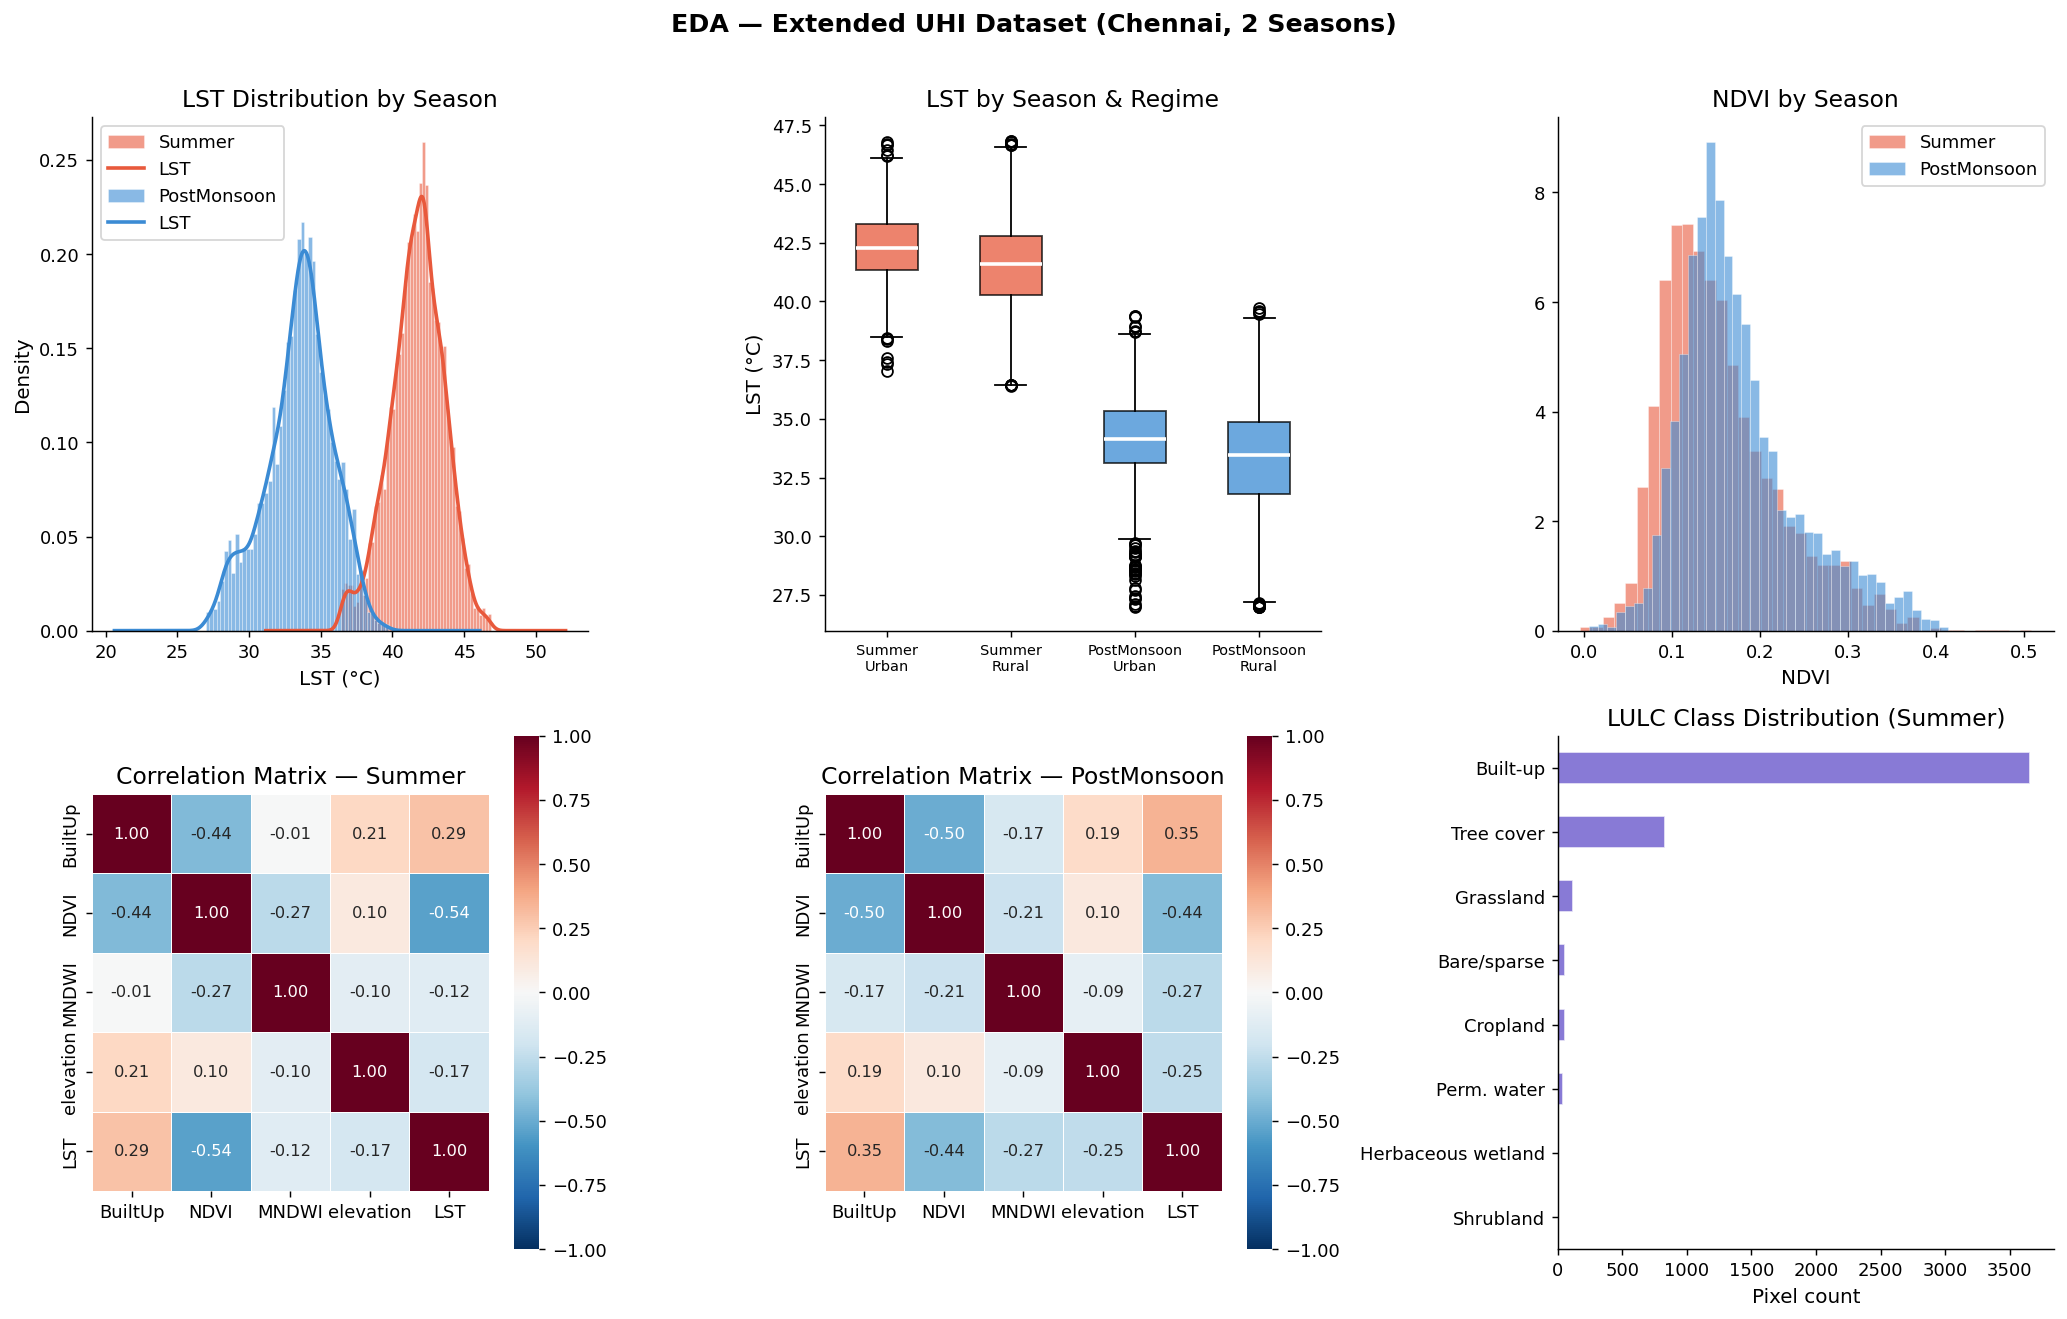

In [ ]:
# CELL 5 — EDA Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA — Extended UHI Dataset (Chennai, 2 Seasons)',
             fontsize=14, fontweight='bold', y=1.01)

# LST distribution by season
ax = axes[0, 0]
for season, color in SEASON_COLORS.items():
    sub = df_all[df_all.SeasonLabel == season]
    ax.hist(sub['LST'], bins=50, alpha=0.6, color=color,
            density=True, label=season, edgecolor='white', linewidth=0.3)
    sub['LST'].plot.kde(ax=ax, color=color, linewidth=2)
ax.set_xlabel('LST (°C)')
ax.set_title('LST Distribution by Season')
ax.legend()

# LST by regime per season boxplot
ax = axes[0, 1]
plot_data, plot_labels, plot_colors = [], [], []
for season in ['Summer', 'PostMonsoon']:
    for regime in ['Urban', 'Rural']:
        sub = df_all[(df_all.SeasonLabel == season) & (df_all.Regime == regime)]
        plot_data.append(sub['LST'].values)
        plot_labels.append(f"{season}\n{regime}")
        plot_colors.append(SEASON_COLORS[season])
bp = ax.boxplot(plot_data, patch_artist=True, widths=0.5,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_xticklabels(plot_labels, fontsize=8)
ax.set_ylabel('LST (°C)')
ax.set_title('LST by Season & Regime')

# NDVI by season
ax = axes[0, 2]
for season, color in SEASON_COLORS.items():
    sub = df_all[df_all.SeasonLabel == season]
    ax.hist(sub['NDVI'], bins=40, alpha=0.6, color=color,
            density=True, label=season, edgecolor='white', linewidth=0.3)
ax.set_xlabel('NDVI')
ax.set_title('NDVI by Season')
ax.legend()

# Correlation heatmap Summer (core features only — readable in paper)
corr_features = ['BuiltUp', 'NDVI', 'MNDWI', 'elevation', 'LST']
ax = axes[1, 0]
corr_s = df_all[df_all.SeasonLabel == 'Summer'][corr_features].corr()
sns.heatmap(corr_s, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, square=True, vmin=-1, vmax=1,
            annot_kws={'size': 9})
ax.set_title('Correlation Matrix — Summer')

# Correlation heatmap PostMonsoon
ax = axes[1, 1]
corr_p = df_all[df_all.SeasonLabel == 'PostMonsoon'][corr_features].corr()
sns.heatmap(corr_p, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, square=True, vmin=-1, vmax=1,
            annot_kws={'size': 9})
ax.set_title('Correlation Matrix — PostMonsoon')

# LULC class distribution (reconstructed from one-hot columns)
ax = axes[1, 2]
lulc_labels = {
    'LULC_10': 'Tree cover',   'LULC_20': 'Shrubland',
    'LULC_30': 'Grassland',    'LULC_40': 'Cropland',
    'LULC_50': 'Built-up',     'LULC_60': 'Bare/sparse',
    'LULC_80': 'Perm. water',  'LULC_90': 'Herbaceous wetland'
}
summer_sub  = df_all[df_all.SeasonLabel == 'Summer']
lulc_counts = summer_sub[lulc_cols].sum().sort_values(ascending=True)
lulc_counts.index = [lulc_labels.get(i, i) for i in lulc_counts.index]
lulc_counts.plot(kind='barh', ax=ax, color='#6B59CC', alpha=0.8, edgecolor='white')
ax.set_title('LULC Class Distribution (Summer)')
ax.set_xlabel('Pixel count')

plt.tight_layout()
plt.savefig('01_EDA_Extended.png', bbox_inches='tight', dpi=150)
plt.show()



In [ ]:
# CELL 6 — Spatial Cross-Validation & Train All 12 Models
# ============================================================

def spatial_cross_val(subset):
    """
    Block-based spatial cross-validation.
    GEE exports pixels in spatial order so sequential index
    approximates geographic position. Splits into 5 geographic
    blocks — train and test pixels are spatially separated.
    """
    X = subset[FEATURES].values
    y = subset[TARGET].values
    n = len(subset)
    n_splits = 5
    block_size = n // n_splits

    blocks = np.repeat(np.arange(n_splits), block_size)
    remainder = n - len(blocks)
    if remainder > 0:
        blocks = np.concatenate([blocks, np.full(remainder, n_splits - 1)])

    np.random.seed(RANDOM_STATE)
    block_ids = np.arange(n_splits)
    np.random.shuffle(block_ids)

    test_mask  = blocks == block_ids[-1]
    train_mask = ~test_mask

    X_tr, X_te = X[train_mask], X[test_mask]
    y_tr, y_te = y[train_mask], y[test_mask]

    sc   = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)

    return X_tr, X_te, y_tr, y_te, sc


RF_PARAMS = dict(n_estimators=300, max_depth=10, min_samples_leaf=5,
                 random_state=RANDOM_STATE, n_jobs=-1)

all_models = {}

print("Training 12 models with spatial cross-validation...\n")
for season in ['Summer', 'PostMonsoon']:
    df_s = df_all[df_all.SeasonLabel == season].copy().reset_index(drop=True)
    for regime in ['Global', 'Urban', 'Rural']:
        if regime == 'Global':
            subset = df_s
        elif regime == 'Urban':
            subset = df_s[df_s.Regime == 'Urban'].reset_index(drop=True)
        else:
            subset = df_s[df_s.Regime == 'Rural'].reset_index(drop=True)

        X_tr, X_te, y_tr, y_te, sc = spatial_cross_val(subset)
        lr = LinearRegression().fit(X_tr, y_tr)
        rf = RandomForestRegressor(**RF_PARAMS).fit(X_tr, y_tr)

        all_models[(season, regime)] = {
            'LR': lr, 'RF': rf,
            'X_tr': X_tr, 'X_te': X_te,
            'y_tr': y_tr, 'y_te': y_te,
            'scaler': sc
        }
        print(f"  {season:12s} | {regime:6s} — trained  (n={len(subset):,})")

print("\nAll 12 models trained.")


Training 12 models with spatial cross-validation...

  Summer       | Global — trained  (n=4,750)
  Summer       | Urban  — trained  (n=1,196)
  Summer       | Rural  — trained  (n=3,554)
  PostMonsoon  | Global — trained  (n=4,733)
  PostMonsoon  | Urban  — trained  (n=1,129)
  PostMonsoon  | Rural  — trained  (n=3,604)

All 12 models trained.


     Season Regime Model     R2   RMSE    MAE
     Summer Global    LR 0.4199 1.4780 1.1690
     Summer Global    RF 0.4470 1.4429 1.1298
     Summer  Urban    LR 0.3176 1.3602 1.0641
     Summer  Urban    RF 0.2886 1.3888 1.0560
     Summer  Rural    LR 0.4248 1.5126 1.2060
     Summer  Rural    RF 0.4482 1.4815 1.1712
PostMonsoon Global    LR 0.4125 1.8102 1.3909
PostMonsoon Global    RF 0.4865 1.6923 1.2574
PostMonsoon  Urban    LR 0.3716 1.6814 1.2891
PostMonsoon  Urban    RF 0.3743 1.6778 1.2099
PostMonsoon  Rural    LR 0.4192 1.8373 1.4145
PostMonsoon  Rural    RF 0.4983 1.7075 1.2739


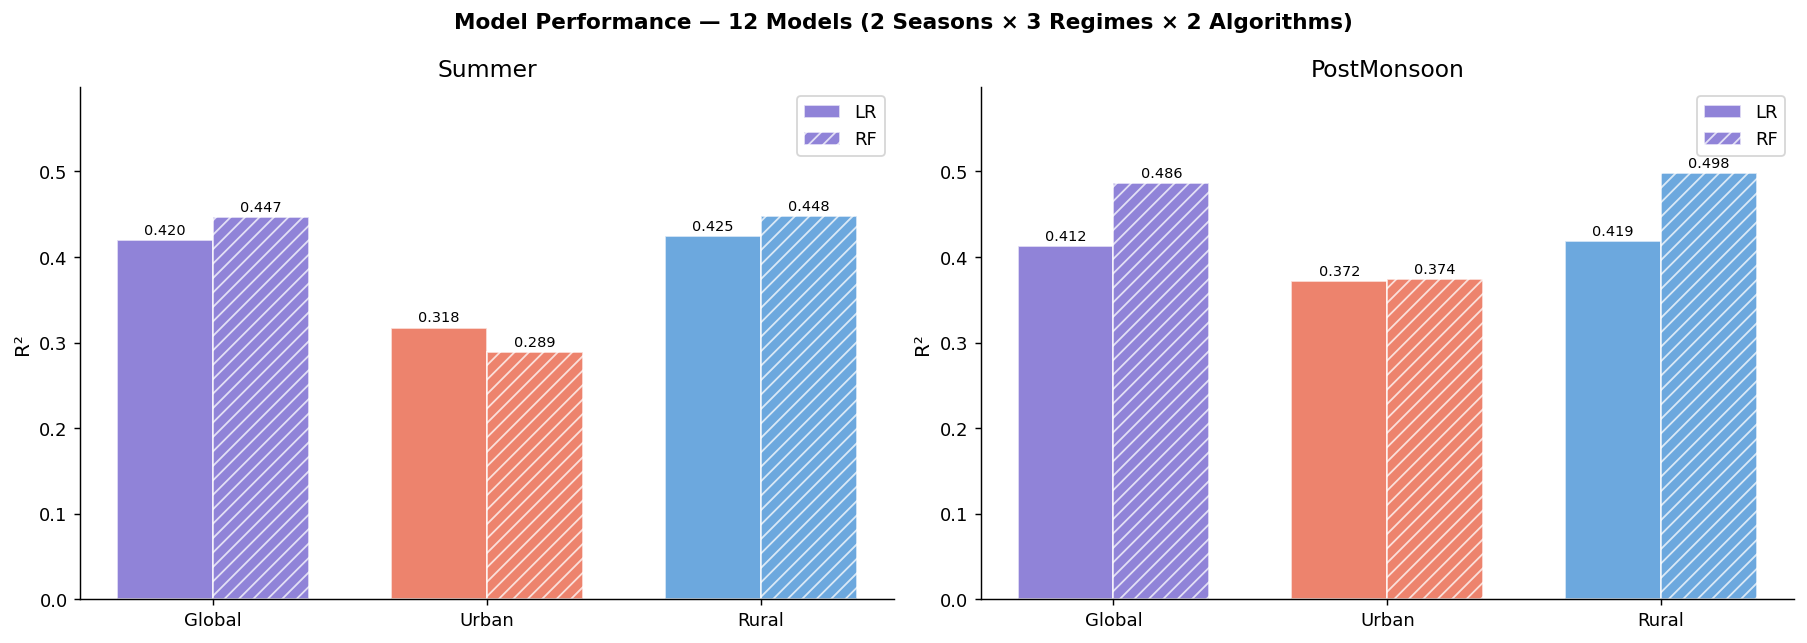

In [ ]:
# CELL 7 — Evaluate All 12 Models
# ============================================================
results = []
for (season, regime), mdict in all_models.items():
    for mname in ['LR', 'RF']:
        pred = mdict[mname].predict(mdict['X_te'])
        results.append({
            'Season': season,
            'Regime': regime,
            'Model':  mname,
            'R2':     round(r2_score(mdict['y_te'], pred), 4),
            'RMSE':   round(np.sqrt(mean_squared_error(mdict['y_te'], pred)), 4),
            'MAE':    round(mean_absolute_error(mdict['y_te'], pred), 4),
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance — 12 Models (2 Seasons × 3 Regimes × 2 Algorithms)',
             fontsize=12, fontweight='bold')

for ax, season in zip(axes, ['Summer', 'PostMonsoon']):
    sub     = results_df[results_df.Season == season]
    regimes = ['Global', 'Urban', 'Rural']
    x       = np.arange(len(regimes))
    width   = 0.35
    for i, (mname, hatch) in enumerate([('LR', ''), ('RF', '///')]):
        vals   = [sub[(sub.Regime == r) & (sub.Model == mname)]['R2'].values[0] for r in regimes]
        colors = [REGIME_COLORS[r] for r in regimes]
        bars   = ax.bar(x + i*width - width/2, vals, width, color=colors,
                        alpha=0.75, hatch=hatch, label=mname, edgecolor='white')
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(regimes)
    ax.set_title(f'{season}')
    ax.set_ylabel('R²')
    ax.set_ylim(0, max(results_df.R2) + 0.1)
    ax.legend()

plt.tight_layout()
plt.savefig('02_ModelPerformance.png', bbox_inches='tight', dpi=150)
plt.show()



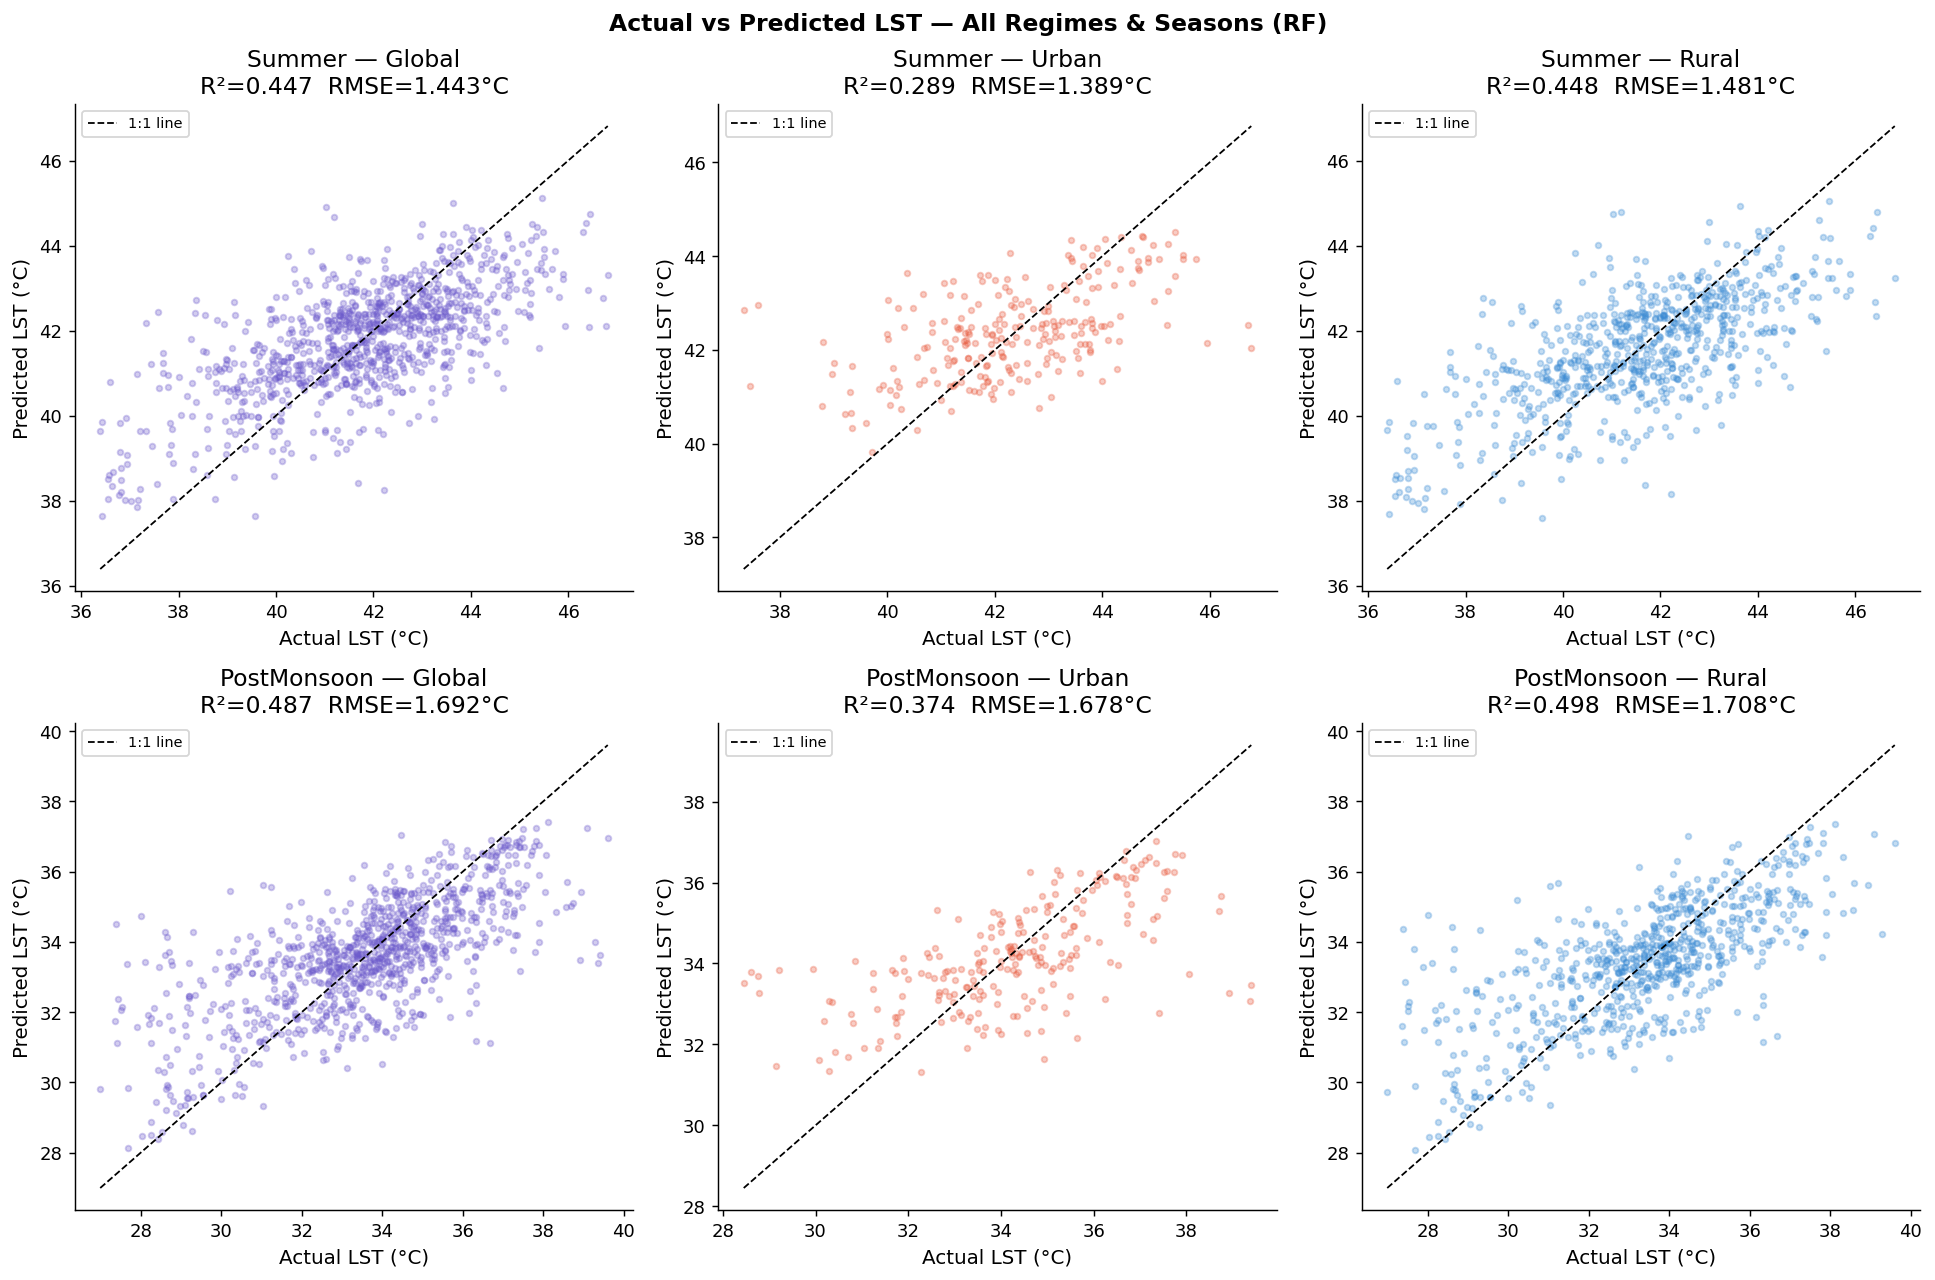

In [ ]:
# CELL 8 — Actual vs Predicted Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Actual vs Predicted LST — All Regimes & Seasons (RF)',
             fontsize=13, fontweight='bold')

for row, season in enumerate(['Summer', 'PostMonsoon']):
    for col, regime in enumerate(['Global', 'Urban', 'Rural']):
        ax     = axes[row, col]
        mdict  = all_models[(season, regime)]
        pred   = mdict['RF'].predict(mdict['X_te'])
        actual = mdict['y_te']
        ax.scatter(actual, pred, alpha=0.3, s=10,
                   color=REGIME_COLORS[regime], rasterized=True)
        mn, mx = actual.min(), actual.max()
        ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1, label='1:1 line')
        r2   = r2_score(actual, pred)
        rmse = np.sqrt(mean_squared_error(actual, pred))
        ax.set_title(f'{season} — {regime}\nR²={r2:.3f}  RMSE={rmse:.3f}°C')
        ax.set_xlabel('Actual LST (°C)')
        ax.set_ylabel('Predicted LST (°C)')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('03_ActualVsPredicted.png', bbox_inches='tight', dpi=150)
plt.show()



In [ ]:
# CELL 9 — Wilcoxon Test: Global vs Regime-Specific
# ============================================================
print("=" * 62)
print("  WILCOXON TEST — Does regime-specific modeling help?")
print("  H0: Global and regime-specific residuals are equal")
print("=" * 62)

wilcoxon_results = []

for season in ['Summer', 'PostMonsoon']:
    global_preds = all_models[(season, 'Global')]['RF'].predict(
                   all_models[(season, 'Global')]['X_te'])
    global_res   = np.abs(all_models[(season, 'Global')]['y_te'] - global_preds)

    for regime in ['Urban', 'Rural']:
        regime_preds = all_models[(season, regime)]['RF'].predict(
                       all_models[(season, regime)]['X_te'])
        regime_res   = np.abs(all_models[(season, regime)]['y_te'] - regime_preds)

        n        = min(len(global_res), len(regime_res))
        stat, p  = wilcoxon(global_res[:n], regime_res[:n])

        wilcoxon_results.append({
            'Season': season, 'Comparison': f'Global vs {regime}',
            'W_stat': round(stat, 1), 'p_value': round(p, 4),
            'Global_MAE': round(global_res.mean(), 4),
            'Regime_MAE': round(regime_res.mean(), 4),
            'Significant': '✓ Yes' if p < 0.05 else '✗ No'
        })

        print(f"\n  {season} | Global vs {regime} RF:")
        print(f"    W={stat:.1f},  p={p:.4f}  "
              f"{'✓ Significantly better' if p < 0.05 else '✗ No significant difference in error'}")
        print(f"    Global MAE={global_res.mean():.4f}°C  |  {regime} MAE={regime_res.mean():.4f}°C")

wilcoxon_df = pd.DataFrame(wilcoxon_results)
print("\n  Note: Non-significant Wilcoxon (p>0.05) means regime-specific models")
print("  do not predict better on average, but SHAP shows they reveal")
print("  structurally different mechanisms — which is the core contribution.")


  WILCOXON TEST — Does regime-specific modeling help?
  H0: Global and regime-specific residuals are equal

  Summer | Global vs Urban RF:
    W=13706.0,  p=0.5535  ✗ No significant difference in error
    Global MAE=1.1298°C  |  Urban MAE=1.0560°C

  Summer | Global vs Rural RF:
    W=122244.0,  p=0.4690  ✗ No significant difference in error
    Global MAE=1.1298°C  |  Rural MAE=1.1712°C

  PostMonsoon | Global vs Urban RF:
    W=12309.0,  p=0.6798  ✗ No significant difference in error
    Global MAE=1.2574°C  |  Urban MAE=1.2099°C

  PostMonsoon | Global vs Rural RF:
    W=129515.0,  p=0.9621  ✗ No significant difference in error
    Global MAE=1.2574°C  |  Rural MAE=1.2739°C

  Note: Non-significant Wilcoxon (p>0.05) means regime-specific models
  do not predict better on average, but SHAP shows they reveal
  structurally different mechanisms — which is the core contribution.


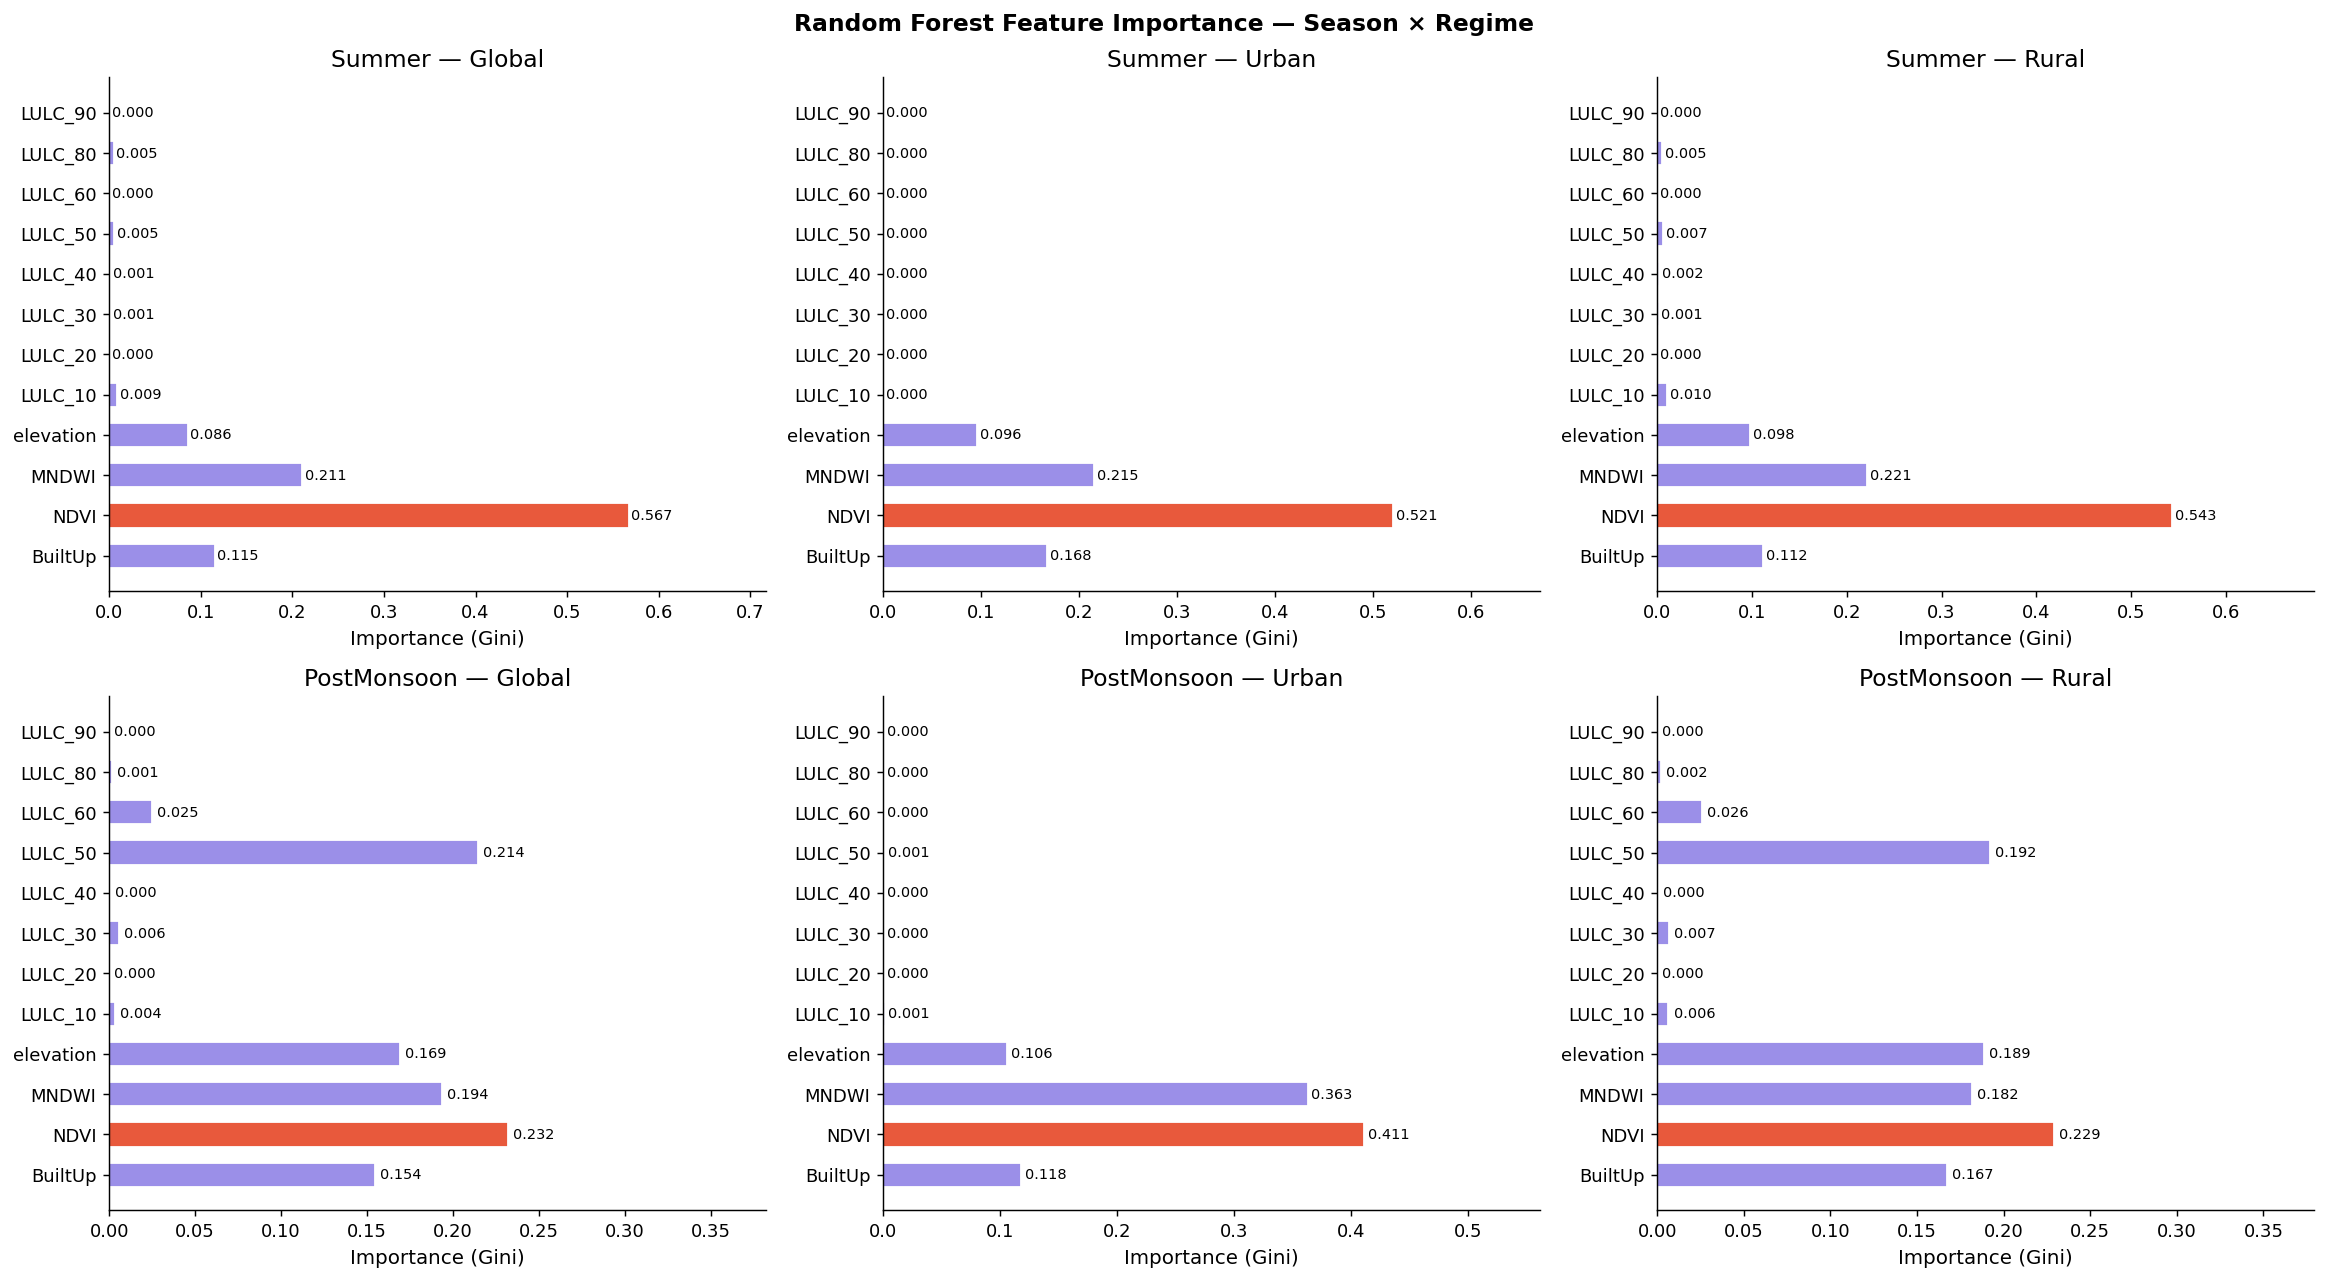


Feature importance shift (Urban - Rural) per season:

  Summer:
    BuiltUp     : Urban=0.168  Rural=0.112  Δ=+0.056
    NDVI        : Urban=0.521  Rural=0.543  Δ=-0.022
    MNDWI       : Urban=0.215  Rural=0.222  Δ=-0.007
    elevation   : Urban=0.096  Rural=0.098  Δ=-0.002
    LULC_10     : Urban=0.000  Rural=0.010  Δ=-0.010
    LULC_20     : Urban=0.000  Rural=0.000  Δ=+0.000
    LULC_30     : Urban=0.000  Rural=0.001  Δ=-0.001
    LULC_40     : Urban=0.000  Rural=0.002  Δ=-0.002
    LULC_50     : Urban=0.000  Rural=0.006  Δ=-0.006
    LULC_60     : Urban=0.000  Rural=0.000  Δ=-0.000
    LULC_80     : Urban=0.000  Rural=0.005  Δ=-0.005
    LULC_90     : Urban=0.000  Rural=0.000  Δ=+0.000

  PostMonsoon:
    BuiltUp     : Urban=0.118  Rural=0.167  Δ=-0.049
    NDVI        : Urban=0.411  Rural=0.229  Δ=+0.182
    MNDWI       : Urban=0.363  Rural=0.182  Δ=+0.181
    elevation   : Urban=0.106  Rural=0.189  Δ=-0.083
    LULC_10     : Urban=0.001  Rural=0.006  Δ=-0.005
    LULC_20     : 

In [ ]:
# CELL 10 — RF Feature Importance by Season & Regime
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Random Forest Feature Importance — Season × Regime',
             fontsize=13, fontweight='bold')

importance_records = []
for row, season in enumerate(['Summer', 'PostMonsoon']):
    for col, regime in enumerate(['Global', 'Urban', 'Rural']):
        ax          = axes[row, col]
        rf          = all_models[(season, regime)]['RF']
        importances = rf.feature_importances_
        colors      = ['#E8593C' if i == np.argmax(importances) else '#9B8FE8'
                       for i in range(len(FEATURES))]
        bars = ax.barh(FEATURES, importances, color=colors,
                       edgecolor='white', height=0.6)
        for bar, val in zip(bars, importances):
            ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=8)
        ax.set_xlim(0, max(importances) + 0.15)
        ax.set_title(f'{season} — {regime}')
        ax.set_xlabel('Importance (Gini)')

        for feat, imp in zip(FEATURES, importances):
            importance_records.append({
                'Season': season, 'Regime': regime,
                'Feature': feat, 'Importance': round(imp, 4)
            })

plt.tight_layout()
plt.savefig('04_FeatureImportance.png', bbox_inches='tight', dpi=150)
plt.show()

imp_df = pd.DataFrame(importance_records)
print("\nFeature importance shift (Urban - Rural) per season:")
for season in ['Summer', 'PostMonsoon']:
    print(f"\n  {season}:")
    urb = imp_df[(imp_df.Season == season) & (imp_df.Regime == 'Urban')].set_index('Feature')['Importance']
    rur = imp_df[(imp_df.Season == season) & (imp_df.Regime == 'Rural')].set_index('Feature')['Importance']
    for feat in FEATURES:
        delta = urb[feat] - rur[feat]
        print(f"    {feat:12s}: Urban={urb[feat]:.3f}  Rural={rur[feat]:.3f}  Δ={delta:+.3f}")

Computing SHAP for Summer Urban RF...


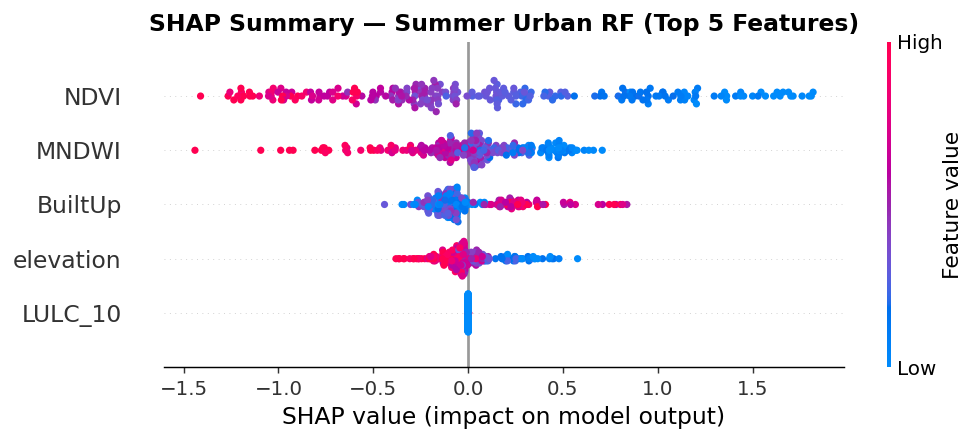

In [ ]:
print("Computing SHAP for Summer Urban RF...")
exp_su  = shap.TreeExplainer(all_models[('Summer', 'Urban')]['RF'])
shap_su = exp_su.shap_values(all_models[('Summer', 'Urban')]['X_te'])

top_n = 5
mean_shap = np.abs(shap_su).mean(axis=0)
top_idx   = np.argsort(mean_shap)[::-1][:top_n]
top_names = [FEATURES[i] for i in top_idx]

plt.figure(figsize=(9, 4))
shap.summary_plot(shap_su[:, top_idx],
                  all_models[('Summer', 'Urban')]['X_te'][:, top_idx],
                  feature_names=top_names, show=False)
plt.title('SHAP Summary — Summer Urban RF (Top 5 Features)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('05_SHAP_Summer_Urban.png', bbox_inches='tight', dpi=150)
plt.show()

Computing SHAP for Summer Rural RF...


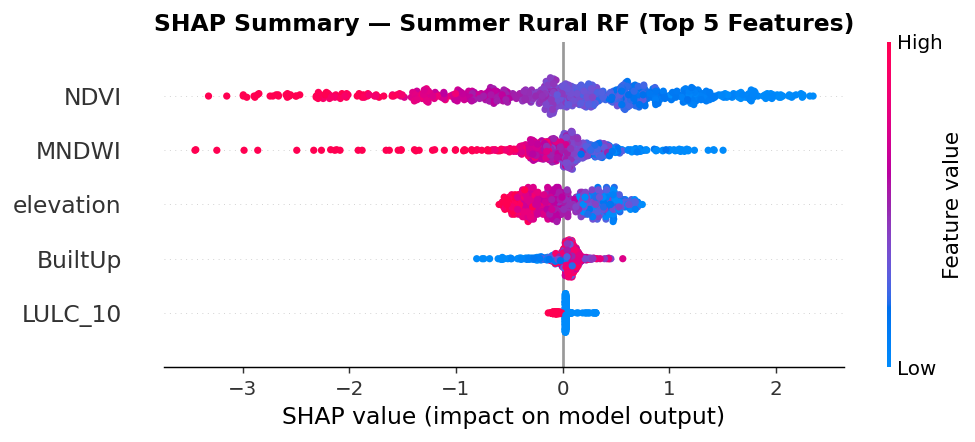

In [ ]:
print("Computing SHAP for Summer Rural RF...")
exp_sr  = shap.TreeExplainer(all_models[('Summer', 'Rural')]['RF'])
shap_sr = exp_sr.shap_values(all_models[('Summer', 'Rural')]['X_te'])

top_n = 5
mean_shap = np.abs(shap_sr).mean(axis=0)
top_idx   = np.argsort(mean_shap)[::-1][:top_n]
top_names = [FEATURES[i] for i in top_idx]

plt.figure(figsize=(9, 4))
shap.summary_plot(shap_sr[:, top_idx],
                  all_models[('Summer', 'Rural')]['X_te'][:, top_idx],
                  feature_names=top_names, show=False)
plt.title('SHAP Summary — Summer Rural RF (Top 5 Features)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_SHAP_Summer_Rural.png', bbox_inches='tight', dpi=150)
plt.show()

Computing SHAP for PostMonsoon Urban RF...


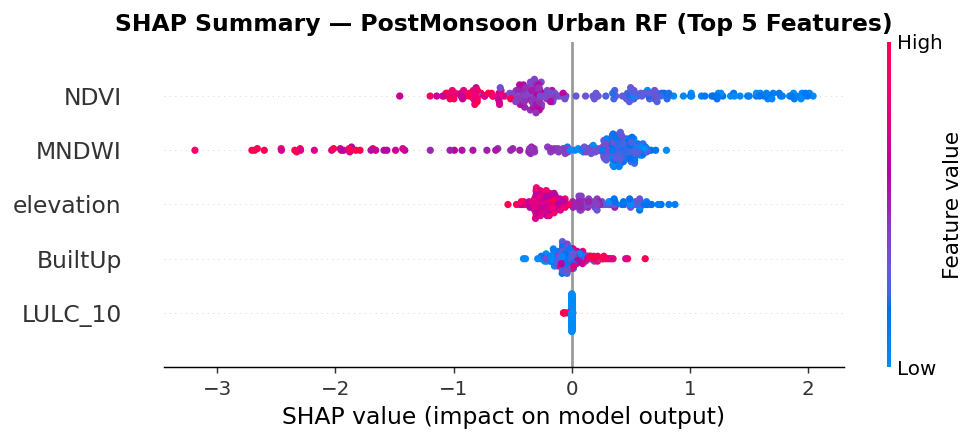

In [ ]:
# CELL 13 — SHAP: PostMonsoon Urban RF
print("Computing SHAP for PostMonsoon Urban RF...")
exp_pu  = shap.TreeExplainer(all_models[('PostMonsoon', 'Urban')]['RF'])
shap_pu = exp_pu.shap_values(all_models[('PostMonsoon', 'Urban')]['X_te'])

top_n = 5
mean_shap = np.abs(shap_pu).mean(axis=0)
top_idx   = np.argsort(mean_shap)[::-1][:top_n]
top_names = [FEATURES[i] for i in top_idx]

plt.figure(figsize=(9, 4))
shap.summary_plot(shap_pu[:, top_idx],
                  all_models[('PostMonsoon', 'Urban')]['X_te'][:, top_idx],
                  feature_names=top_names, show=False)
plt.title('SHAP Summary — PostMonsoon Urban RF (Top 5 Features)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_SHAP_PostMonsoon_Urban.png', bbox_inches='tight', dpi=150)
plt.show()

Computing SHAP for PostMonsoon Rural RF...


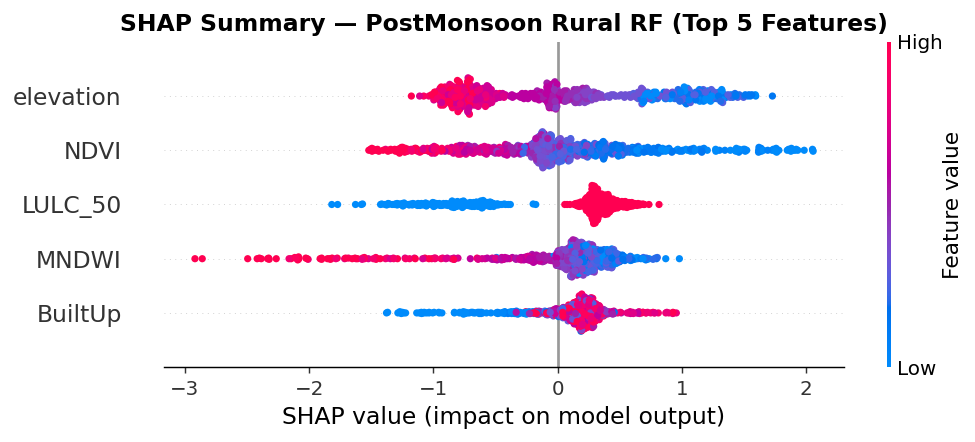

In [ ]:
# CELL 14 — SHAP: PostMonsoon Rural RF
print("Computing SHAP for PostMonsoon Rural RF...")
exp_pr  = shap.TreeExplainer(all_models[('PostMonsoon', 'Rural')]['RF'])
shap_pr = exp_pr.shap_values(all_models[('PostMonsoon', 'Rural')]['X_te'])

top_n = 5
mean_shap = np.abs(shap_pr).mean(axis=0)
top_idx   = np.argsort(mean_shap)[::-1][:top_n]
top_names = [FEATURES[i] for i in top_idx]

plt.figure(figsize=(9, 4))
shap.summary_plot(shap_pr[:, top_idx],
                  all_models[('PostMonsoon', 'Rural')]['X_te'][:, top_idx],
                  feature_names=top_names, show=False)
plt.title('SHAP Summary — PostMonsoon Rural RF (Top 5 Features)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('08_SHAP_PostMonsoon_Rural.png', bbox_inches='tight', dpi=150)
plt.show()

Mean |SHAP| values:
                    BuiltUp    NDVI   MNDWI  elevation  LULC_10  LULC_20  \
Summer\nUrban        0.1759  0.6587  0.2540     0.1138   0.0001      0.0   
Summer\nRural        0.1090  0.8634  0.3265     0.2891   0.0415      0.0   
PostMonsoon\nUrban   0.1052  0.7341  0.6222     0.2626   0.0031      0.0   
PostMonsoon\nRural   0.2760  0.5203  0.3950     0.6513   0.0258      0.0   

                    LULC_30  LULC_40  LULC_50  LULC_60  LULC_80  LULC_90  
Summer\nUrban        0.0000   0.0000   0.0001   0.0000   0.0000      0.0  
Summer\nRural        0.0018   0.0023   0.0271   0.0004   0.0073      0.0  
PostMonsoon\nUrban   0.0000   0.0000   0.0009   0.0000   0.0000      0.0  
PostMonsoon\nRural   0.0096   0.0005   0.5156   0.0313   0.0044      0.0  


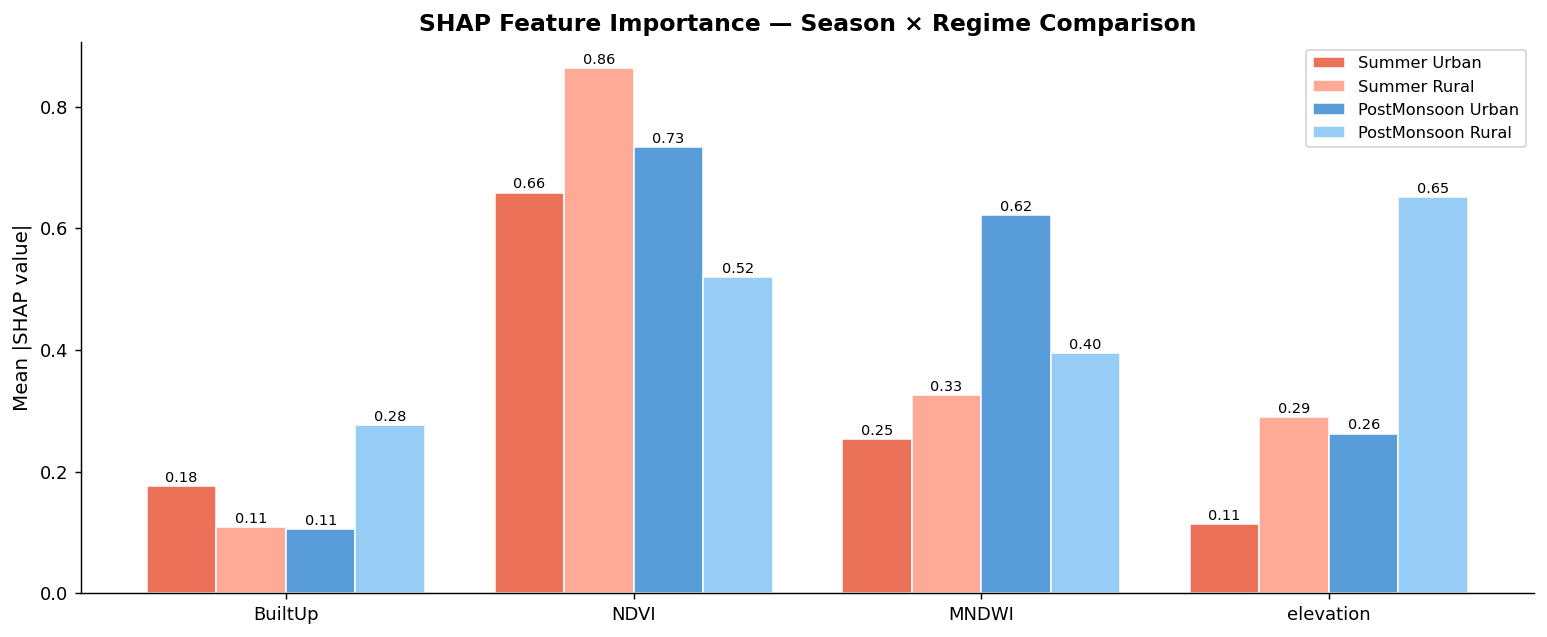

In [ ]:
# CELL 15 — SHAP Mean |Values|: Full Season × Regime Comparison
# ============================================================
shap_configs = {
    ('Summer',      'Urban'): (shap_su, all_models[('Summer',      'Urban')]['X_te']),
    ('Summer',      'Rural'): (shap_sr, all_models[('Summer',      'Rural')]['X_te']),
    ('PostMonsoon', 'Urban'): (shap_pu, all_models[('PostMonsoon', 'Urban')]['X_te']),
    ('PostMonsoon', 'Rural'): (shap_pr, all_models[('PostMonsoon', 'Rural')]['X_te']),
}

shap_summary = {}
for (season, regime), (sv, Xte) in shap_configs.items():
    shap_summary[f'{season}\n{regime}'] = np.abs(sv).mean(axis=0)

shap_comp_df = pd.DataFrame(shap_summary, index=FEATURES).T
print("Mean |SHAP| values:")
print(shap_comp_df.round(4))

# Plot top 4 features only (cleaner for paper)
top_features = ['BuiltUp', 'NDVI', 'MNDWI', 'elevation']
top_idx      = [FEATURES.index(f) for f in top_features]

fig, ax = plt.subplots(figsize=(12, 5))
x           = np.arange(len(top_features))
width       = 0.2
bar_colors  = ['#E8593C', '#FF9B85', '#3B8BD4', '#85C4F5']
labels      = ['Summer Urban', 'Summer Rural', 'PostMonsoon Urban', 'PostMonsoon Rural']

for i, (label, color) in enumerate(zip(labels, bar_colors)):
    key  = label.replace(' ', '\n', 1)
    vals = [shap_comp_df.loc[key, f] for f in top_features]
    bars = ax.bar(x + (i - 1.5)*width, vals, width, label=label,
                  color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(top_features)
ax.set_ylabel('Mean |SHAP value|')
ax.set_title('SHAP Feature Importance — Season × Regime Comparison', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('09_SHAP_Comparison.png', bbox_inches='tight', dpi=150)
plt.show()


In [ ]:
# CELL 16 — Seasonal Stability Analysis
# ============================================================
print("=" * 62)
print("  SEASONAL STABILITY OF FEATURE IMPORTANCE")
print("=" * 62)

for regime in ['Urban', 'Rural']:
    print(f"\n  {regime} regime:")
    print(f"  {'Feature':<12} {'Summer':>10} {'PostMonsoon':>13} {'Δ':>8} {'Stable?':>10}")
    print("  " + "-" * 56)
    for feat in FEATURES:
        s_imp = imp_df[(imp_df.Season == 'Summer') &
                       (imp_df.Regime == regime) &
                       (imp_df.Feature == feat)]['Importance'].values[0]
        p_imp = imp_df[(imp_df.Season == 'PostMonsoon') &
                       (imp_df.Regime == regime) &
                       (imp_df.Feature == feat)]['Importance'].values[0]
        delta  = abs(s_imp - p_imp)
        stable = '✓ Stable' if delta < 0.05 else '~ Shifts'
        print(f"  {feat:<12} {s_imp:>10.3f} {p_imp:>13.3f} {delta:>8.3f} {stable:>10}")



  SEASONAL STABILITY OF FEATURE IMPORTANCE

  Urban regime:
  Feature          Summer   PostMonsoon        Δ    Stable?
  --------------------------------------------------------
  BuiltUp           0.168         0.118    0.050   ✓ Stable
  NDVI              0.521         0.411    0.110   ~ Shifts
  MNDWI             0.215         0.363    0.148   ~ Shifts
  elevation         0.096         0.106    0.010   ✓ Stable
  LULC_10           0.000         0.001    0.001   ✓ Stable
  LULC_20           0.000         0.000    0.000   ✓ Stable
  LULC_30           0.000         0.000    0.000   ✓ Stable
  LULC_40           0.000         0.000    0.000   ✓ Stable
  LULC_50           0.000         0.001    0.001   ✓ Stable
  LULC_60           0.000         0.000    0.000   ✓ Stable
  LULC_80           0.000         0.000    0.000   ✓ Stable
  LULC_90           0.000         0.000    0.000   ✓ Stable

  Rural regime:
  Feature          Summer   PostMonsoon        Δ    Stable?
  ----------------------

In [ ]:
# CELL 17 — Final Summary
# ============================================================
print("=" * 62)
print("  FINAL RESULTS SUMMARY — IEEE SUBMISSION")
print("=" * 62)

s_mean = df_all[df_all.SeasonLabel == 'Summer']['LST'].mean()
p_mean = df_all[df_all.SeasonLabel == 'PostMonsoon']['LST'].mean()

print(f"\n  Dataset   : {len(df_all):,} pixels | 2 seasons | {len(FEATURES)} features")
print(f"  Features  : {FEATURES}")
print(f"  Threshold : BuiltUp >= {BUILTUP_THR} = Urban")
print(f"\n  Seasonal LST:")
print(f"    Summer mean      : {s_mean:.2f}°C")
print(f"    PostMonsoon mean : {p_mean:.2f}°C")
print(f"    Seasonal gap     : {s_mean - p_mean:.2f}°C")

print(f"\n  Model Performance (RF):")
print(f"  {'Season':<14} {'Regime':<8} {'R2':>6} {'RMSE':>7} {'MAE':>7}")
print("  " + "-" * 44)
for _, row in results_df[results_df.Model == 'RF'].iterrows():
    print(f"  {row.Season:<14} {row.Regime:<8} {row.R2:>6.4f} {row.RMSE:>7.4f} {row.MAE:>7.4f}")

print(f"\n  Wilcoxon Tests:")
for _, row in wilcoxon_df.iterrows():
    print(f"    {row.Season} | {row.Comparison}: p={row.p_value}  {row.Significant}")

print(f"\n  Saved figures: 01_EDA through 09_SHAP_Comparison")

su_key = 'Summer\nUrban'
pu_key = 'PostMonsoon\nUrban'
if su_key in shap_comp_df.index and pu_key in shap_comp_df.index:
    print(f"\n  Key finding: MNDWI importance shifts from {shap_comp_df.loc[su_key,'MNDWI']:.2f} (Summer Urban)")
    print(f"  to {shap_comp_df.loc[pu_key,'MNDWI']:.2f} (PostMonsoon Urban) — water proximity")
    print(f"  becomes dominant urban thermal regulator after monsoon.")
else:
    print(f"\n  SHAP index keys: {list(shap_comp_df.index)}")

  FINAL RESULTS SUMMARY — IEEE SUBMISSION

  Dataset   : 9,483 pixels | 2 seasons | 12 features
  Features  : ['BuiltUp', 'NDVI', 'MNDWI', 'elevation', 'LULC_10', 'LULC_20', 'LULC_30', 'LULC_40', 'LULC_50', 'LULC_60', 'LULC_80', 'LULC_90']
  Threshold : BuiltUp >= 4976 = Urban

  Seasonal LST:
    Summer mean      : 41.70°C
    PostMonsoon mean : 33.47°C
    Seasonal gap     : 8.23°C

  Model Performance (RF):
  Season         Regime       R2    RMSE     MAE
  --------------------------------------------
  Summer         Global   0.4470  1.4429  1.1298
  Summer         Urban    0.2886  1.3888  1.0560
  Summer         Rural    0.4482  1.4815  1.1712
  PostMonsoon    Global   0.4865  1.6923  1.2574
  PostMonsoon    Urban    0.3743  1.6778  1.2099
  PostMonsoon    Rural    0.4983  1.7075  1.2739

  Wilcoxon Tests:
    Summer | Global vs Urban: p=0.5535  ✗ No
    Summer | Global vs Rural: p=0.469  ✗ No
    PostMonsoon | Global vs Urban: p=0.6798  ✗ No
    PostMonsoon | Global vs Rural: p=0